In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import matplotlib.gridspec as gridspec

Визуализация гибридного AMM для RWA токенов
1. Статическая визуализация всех кривых...


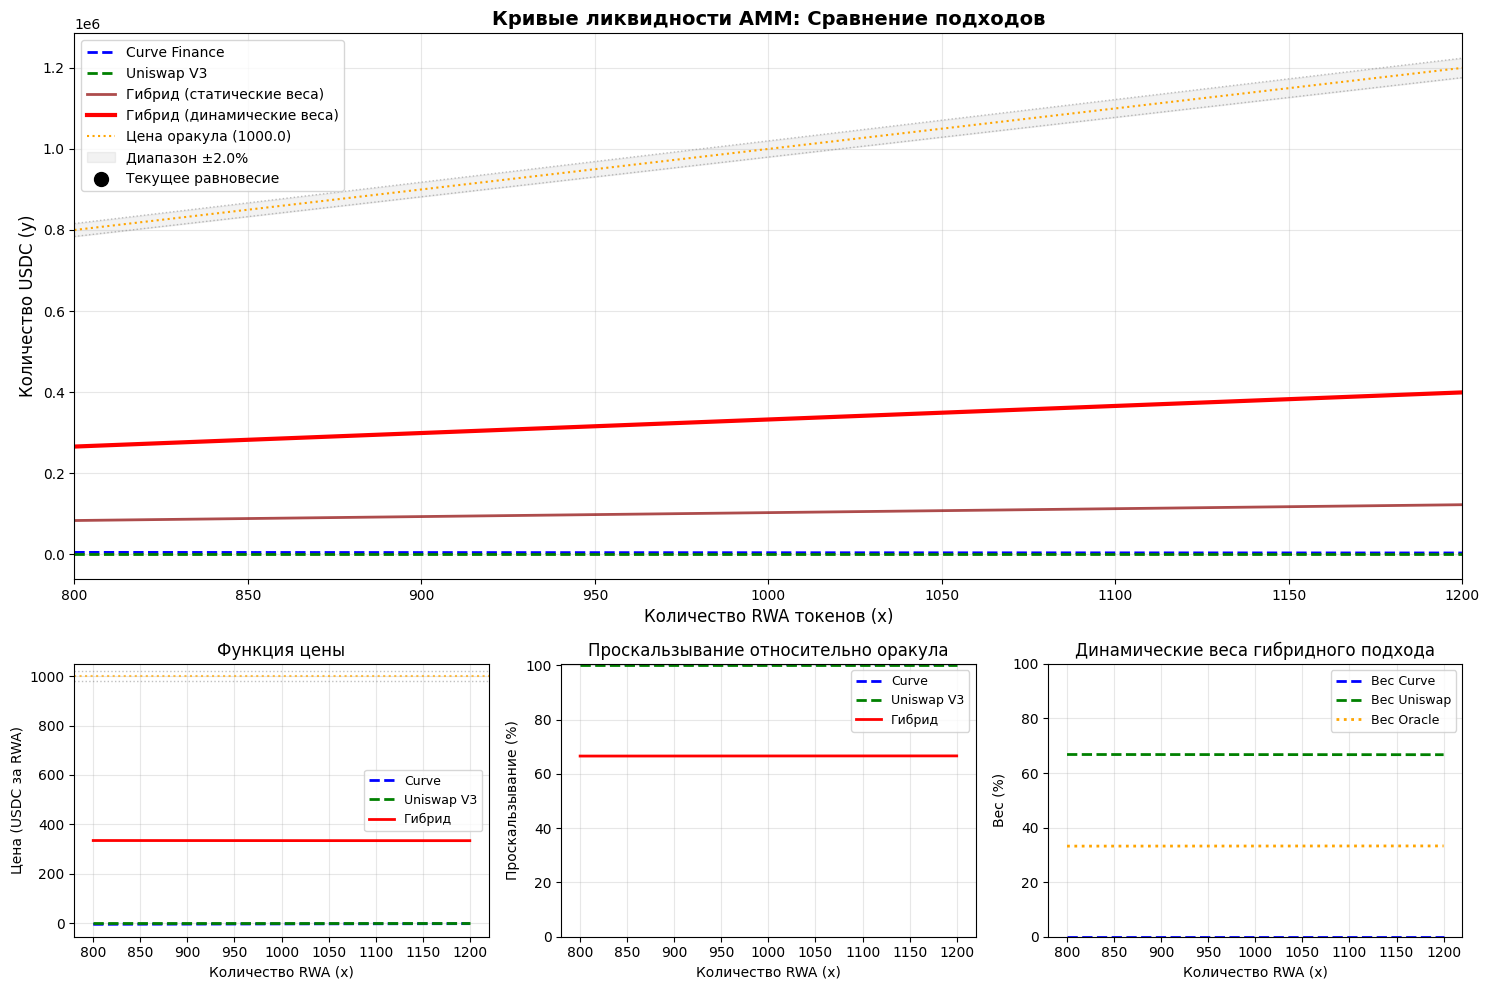


2. Сравнение цен при разных объемах...


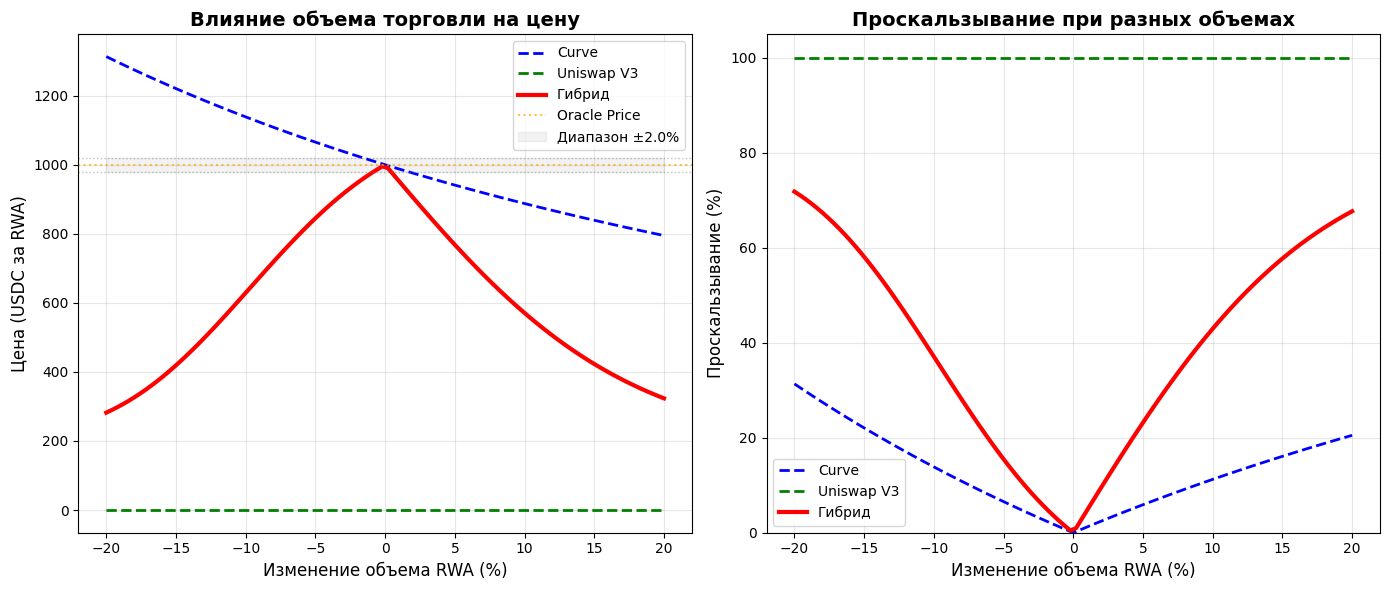

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec


class AMMVisualizer:
    def __init__(self):
        self.A = 100.0
        self.L = 1000.0
        self.P_oracle = 1000.0
        self.delta = 0.02

        self.alpha = 0.7
        self.beta = 0.2
        self.gamma = 0.1

        self.x_min = 800
        self.x_max = 1200
        self.x_points = 500

        self.x = np.linspace(self.x_min, self.x_max, self.x_points)

        self.colors = {
            'curve': 'blue',
            'uniswap': 'green',
            'hybrid': 'red',
            'oracle': 'orange',
            'bounds': 'gray'
        }

        self.linestyles = {
            'curve': '--',
            'uniswap': '--',
            'hybrid': '-',
            'oracle': ':',
            'bounds': ':'
        }

    def calculate_curve(self, x):
        x0 = self.L / np.sqrt(self.P_oracle)
        y0 = self.L * np.sqrt(self.P_oracle)

        const = self.A * (x0 + y0) + x0 * y0
        y_curve = np.zeros_like(x)

        for i, x_val in enumerate(x):
            if x_val <= 0:
                y_curve[i] = 0
                continue

            y_guess = y0

            for _ in range(10):
                f = self.A * (x_val + y_guess) + x_val * y_guess - const
                f_prime = self.A + x_val

                if f_prime == 0:
                    break

                y_guess = y_guess - f / f_prime

                if y_guess < 0:
                    y_guess = 0
                    break

            y_curve[i] = y_guess

        return y_curve

    def calculate_uniswap_v3(self, x):
        P_a = self.P_oracle * (1 - self.delta)
        P_b = self.P_oracle * (1 + self.delta)

        L_uni = self.L

        x_min = 0
        x_max = L_uni / np.sqrt(P_a) - L_uni / np.sqrt(P_b)

        y_uni = np.zeros_like(x)

        for i, x_val in enumerate(x):
            if x_val < x_min:
                y_uni[i] = L_uni * np.sqrt(P_b) - L_uni * np.sqrt(P_a)
            elif x_val > x_max:
                y_uni[i] = 0
            else:
                term = x_val / L_uni + 1 / np.sqrt(P_b)
                if term <= 0:
                    P = P_a
                else:
                    P = min(P_b, max(P_a, 1 / (term ** 2)))

                y_uni[i] = L_uni * np.sqrt(P) - L_uni * np.sqrt(P_a)

        return y_uni

    def calculate_hybrid(self, x, use_dynamic_weights=True):
        y_curve = self.calculate_curve(x)
        y_uni = self.calculate_uniswap_v3(x)
        y_oracle = self.P_oracle * x

        if not use_dynamic_weights:
            return (
                self.alpha * y_curve +
                self.beta * y_uni +
                self.gamma * y_oracle
            )

        y_hybrid = np.zeros_like(x)

        for i, x_val in enumerate(x):
            if x_val <= 0:
                y_hybrid[i] = 0
                continue

            price_curve = y_curve[i] / x_val
            deviation = abs(price_curve - self.P_oracle) / self.P_oracle

            alpha_dyn = np.exp(-10 * deviation) * self.alpha
            beta_dyn = (1 - np.exp(-10 * deviation)) * self.beta
            gamma_dyn = deviation * self.gamma

            total = alpha_dyn + beta_dyn + gamma_dyn

            if total > 0:
                alpha_norm = alpha_dyn / total
                beta_norm = beta_dyn / total
                gamma_norm = gamma_dyn / total
            else:
                alpha_norm = beta_norm = gamma_norm = 1 / 3

            y_hybrid[i] = (
                alpha_norm * y_curve[i] +
                beta_norm * y_uni[i] +
                gamma_norm * y_oracle[i]
            )

        return y_hybrid

    def calculate_prices(self, x):
        y_curve = self.calculate_curve(x)
        y_uni = self.calculate_uniswap_v3(x)
        y_hybrid = self.calculate_hybrid(x)

        prices = {
            'curve': np.zeros_like(x),
            'uniswap': np.zeros_like(x),
            'hybrid': np.zeros_like(x)
        }

        for i in range(1, len(x) - 1):
            dx = x[i + 1] - x[i - 1]
            if dx != 0:
                prices['curve'][i] = (y_curve[i + 1] - y_curve[i - 1]) / dx
                prices['uniswap'][i] = (y_uni[i + 1] - y_uni[i - 1]) / dx
                prices['hybrid'][i] = (y_hybrid[i + 1] - y_hybrid[i - 1]) / dx

        prices['curve'][0] = prices['curve'][1]
        prices['curve'][-1] = prices['curve'][-2]
        prices['uniswap'][0] = prices['uniswap'][1]
        prices['uniswap'][-1] = prices['uniswap'][-2]
        prices['hybrid'][0] = prices['hybrid'][1]
        prices['hybrid'][-1] = prices['hybrid'][-2]

        return prices

    def plot_amm_curves(self):
        fig = plt.figure(figsize=(15, 10))
        gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1])

        ax1 = plt.subplot(gs[0, :])

        y_curve = self.calculate_curve(self.x)
        y_uni = self.calculate_uniswap_v3(self.x)
        y_hybrid_static = self.calculate_hybrid(self.x, use_dynamic_weights=False)
        y_hybrid_dynamic = self.calculate_hybrid(self.x, use_dynamic_weights=True)
        y_oracle = self.P_oracle * self.x

        P_a = self.P_oracle * (1 - self.delta)
        P_b = self.P_oracle * (1 + self.delta)
        y_lower = P_a * self.x
        y_upper = P_b * self.x

        ax1.plot(self.x, y_curve, color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Curve Finance')
        ax1.plot(self.x, y_uni, color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Uniswap V3')
        ax1.plot(self.x, y_hybrid_static, color='darkred',
                 linestyle='-', linewidth=2, alpha=0.7, label='Гибрид (статические веса)')
        ax1.plot(self.x, y_hybrid_dynamic, color=self.colors['hybrid'],
                 linestyle=self.linestyles['hybrid'], linewidth=3, label='Гибрид (динамические веса)')
        ax1.plot(self.x, y_oracle, color=self.colors['oracle'],
                 linestyle=self.linestyles['oracle'], linewidth=1.5, label=f'Цена оракула ({self.P_oracle})')

        ax1.plot(self.x, y_lower, color=self.colors['bounds'],
                 linestyle=self.linestyles['bounds'], linewidth=1, alpha=0.5)
        ax1.plot(self.x, y_upper, color=self.colors['bounds'],
                 linestyle=self.linestyles['bounds'], linewidth=1, alpha=0.5)
        ax1.fill_between(self.x, y_lower, y_upper, alpha=0.1, color='gray',
                         label=f'Диапазон ±{self.delta * 100:.1f}%')

        x_eq = self.L / np.sqrt(self.P_oracle)
        y_eq = self.L * np.sqrt(self.P_oracle)
        ax1.scatter([x_eq], [y_eq], color='black', s=100, zorder=5, label='Текущее равновесие')

        ax1.set_xlabel('Количество RWA токенов (x)', fontsize=12)
        ax1.set_ylabel('Количество USDC (y)', fontsize=12)
        ax1.set_title('Кривые ликвидности AMM: Сравнение подходов', fontsize=14, fontweight='bold')
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(self.x_min, self.x_max)

        ax2 = plt.subplot(gs[1, 0])
        prices = self.calculate_prices(self.x)

        ax2.plot(self.x, prices['curve'], color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Curve')
        ax2.plot(self.x, prices['uniswap'], color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Uniswap V3')
        ax2.plot(self.x, prices['hybrid'], color=self.colors['hybrid'],
                 linestyle=self.linestyles['hybrid'], linewidth=2, label='Гибрид')

        ax2.axhline(y=self.P_oracle, color=self.colors['oracle'],
                    linestyle=self.linestyles['oracle'], linewidth=1.5, alpha=0.7)
        ax2.axhline(y=P_a, color=self.colors['bounds'], linestyle=':', linewidth=1, alpha=0.5)
        ax2.axhline(y=P_b, color=self.colors['bounds'], linestyle=':', linewidth=1, alpha=0.5)

        ax2.set_xlabel('Количество RWA (x)')
        ax2.set_ylabel('Цена (USDC за RWA)')
        ax2.set_title('Функция цены', fontsize=12)
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)

        ax3 = plt.subplot(gs[1, 1])

        slippage_curve = 100 * abs(prices['curve'] - self.P_oracle) / self.P_oracle
        slippage_uniswap = 100 * abs(prices['uniswap'] - self.P_oracle) / self.P_oracle
        slippage_hybrid = 100 * abs(prices['hybrid'] - self.P_oracle) / self.P_oracle

        ax3.plot(self.x, slippage_curve, color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Curve')
        ax3.plot(self.x, slippage_uniswap, color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Uniswap V3')
        ax3.plot(self.x, slippage_hybrid, color=self.colors['hybrid'],
                 linestyle=self.linestyles['hybrid'], linewidth=2, label='Гибрид')

        ax3.set_xlabel('Количество RWA (x)')
        ax3.set_ylabel('Проскальзывание (%)')
        ax3.set_title('Проскальзывание относительно оракула', fontsize=12)
        ax3.legend(loc='best', fontsize=9)
        ax3.grid(True, alpha=0.3)
        ax3.set_ylim(0, max(10, slippage_curve.max(), slippage_uniswap.max(), slippage_hybrid.max()))

        ax4 = plt.subplot(gs[1, 2])

        y_curve = self.calculate_curve(self.x)
        weights_curve = np.zeros_like(self.x)
        weights_uniswap = np.zeros_like(self.x)
        weights_oracle = np.zeros_like(self.x)

        for i, x_val in enumerate(self.x):
            if x_val <= 0:
                continue

            price_curve = y_curve[i] / x_val
            deviation = abs(price_curve - self.P_oracle) / self.P_oracle

            alpha_dyn = np.exp(-10 * deviation) * self.alpha
            beta_dyn = (1 - np.exp(-10 * deviation)) * self.beta
            gamma_dyn = deviation * self.gamma

            total = alpha_dyn + beta_dyn + gamma_dyn
            if total > 0:
                weights_curve[i] = 100 * alpha_dyn / total
                weights_uniswap[i] = 100 * beta_dyn / total
                weights_oracle[i] = 100 * gamma_dyn / total

        ax4.plot(self.x, weights_curve, color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Вес Curve')
        ax4.plot(self.x, weights_uniswap, color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Вес Uniswap')
        ax4.plot(self.x, weights_oracle, color=self.colors['oracle'],
                 linestyle=self.linestyles['oracle'], linewidth=2, label='Вес Oracle')

        ax4.set_xlabel('Количество RWA (x)')
        ax4.set_ylabel('Вес (%)')
        ax4.set_title('Динамические веса гибридного подхода', fontsize=12)
        ax4.legend(loc='best', fontsize=9)
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim(0, 100)

        plt.tight_layout()
        plt.show()

    def plot_price_comparison(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        x_base = self.L / np.sqrt(self.P_oracle)
        trade_ratios = np.linspace(-0.2, 0.2, 100)
        trade_amounts = trade_ratios * x_base

        prices_curve = []
        prices_uniswap = []
        prices_hybrid = []

        for trade in trade_amounts:
            x_new = x_base + trade

            y_curve = self.calculate_curve(np.array([x_new]))[0]
            y_uni = self.calculate_uniswap_v3(np.array([x_new]))[0]
            y_hybrid = self.calculate_hybrid(np.array([x_new]))[0]

            if x_new > 0:
                prices_curve.append(y_curve / x_new)
                prices_uniswap.append(y_uni / x_new)
                prices_hybrid.append(y_hybrid / x_new)
            else:
                prices_curve.append(0)
                prices_uniswap.append(0)
                prices_hybrid.append(0)

        ax1.plot(trade_ratios * 100, prices_curve, color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Curve')
        ax1.plot(trade_ratios * 100, prices_uniswap, color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Uniswap V3')
        ax1.plot(trade_ratios * 100, prices_hybrid, color=self.colors['hybrid'],
                 linestyle=self.linestyles['hybrid'], linewidth=3, label='Гибрид')

        ax1.axhline(y=self.P_oracle, color=self.colors['oracle'],
                    linestyle=self.linestyles['oracle'], linewidth=1.5, alpha=0.7, label='Oracle Price')

        P_a = self.P_oracle * (1 - self.delta)
        P_b = self.P_oracle * (1 + self.delta)
        ax1.axhline(y=P_a, color=self.colors['bounds'], linestyle=':', linewidth=1, alpha=0.5)
        ax1.axhline(y=P_b, color=self.colors['bounds'], linestyle=':', linewidth=1, alpha=0.5)
        ax1.fill_between(trade_ratios * 100, P_a, P_b, alpha=0.1, color='gray',
                         label=f'Диапазон ±{self.delta * 100:.1f}%')

        ax1.set_xlabel('Изменение объема RWA (%)', fontsize=12)
        ax1.set_ylabel('Цена (USDC за RWA)', fontsize=12)
        ax1.set_title('Влияние объема торговли на цену', fontsize=14, fontweight='bold')
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)

        slippage_curve = 100 * abs(np.array(prices_curve) - self.P_oracle) / self.P_oracle
        slippage_uniswap = 100 * abs(np.array(prices_uniswap) - self.P_oracle) / self.P_oracle
        slippage_hybrid = 100 * abs(np.array(prices_hybrid) - self.P_oracle) / self.P_oracle

        ax2.plot(trade_ratios * 100, slippage_curve, color=self.colors['curve'],
                 linestyle=self.linestyles['curve'], linewidth=2, label='Curve')
        ax2.plot(trade_ratios * 100, slippage_uniswap, color=self.colors['uniswap'],
                 linestyle=self.linestyles['uniswap'], linewidth=2, label='Uniswap V3')
        ax2.plot(trade_ratios * 100, slippage_hybrid, color=self.colors['hybrid'],
                 linestyle=self.linestyles['hybrid'], linewidth=3, label='Гибрид')

        ax2.set_xlabel('Изменение объема RWA (%)', fontsize=12)
        ax2.set_ylabel('Проскальзывание (%)', fontsize=12)
        ax2.set_title('Проскальзывание при разных объемах', fontsize=14, fontweight='bold')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()

    def plot_3d_surface(self):
        from mpl_toolkits.mplot3d import Axes3D

        A_values = np.linspace(50, 200, 20)
        delta_values = np.linspace(0.01, 0.05, 20)

        x_base = self.L / np.sqrt(self.P_oracle)
        x_test = 1.1 * x_base

        slippage_matrix = np.zeros((len(A_values), len(delta_values)))

        for i, A in enumerate(A_values):
            for j, delta in enumerate(delta_values):
                original_A = self.A
                original_delta = self.delta

                self.A = A
                self.delta = delta

                y_hybrid = self.calculate_hybrid(np.array([x_test]))[0]
                price = y_hybrid / x_test if x_test > 0 else 0
                slippage_matrix[i, j] = 100 * abs(price - self.P_oracle) / self.P_oracle

                self.A = original_A
                self.delta = original_delta

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        A_grid, delta_grid = np.meshgrid(delta_values, A_values)

        surf = ax.plot_surface(A_grid, delta_grid, slippage_matrix, cmap='viridis', alpha=0.8)

        ax.set_xlabel('Price Band (Δ)', fontsize=12)
        ax.set_ylabel('Amplification (A)', fontsize=12)
        ax.set_zlabel('Проскальзывание (%)', fontsize=12)
        ax.set_title('Зависимость проскальзывания от параметров A и Δ', fontsize=14, fontweight='bold')

        fig.colorbar(surf, shrink=0.5, aspect=5)
        plt.show()


if __name__ == "__main__":
    print("Визуализация гибридного AMM для RWA токенов")
    print("=" * 50)

    visualizer = AMMVisualizer()

    print("1. Статическая визуализация всех кривых...")
    visualizer.plot_amm_curves()

    print("\n2. Сравнение цен при разных объемах...")
    visualizer.plot_price_comparison()

    # print("\n3. 3D визуализация поверхности...")
    # visualizer.plot_3d_surface()